<a href="https://colab.research.google.com/github/Bhavninder/AQI-Project/blob/main/AQI_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (65288, 16)

Columns:
 Index(['RecordID', 'Datetime', 'City', 'Station', 'PM25', 'PM10', 'NO2', 'SO2',
       'CO_mg_m3', 'O3', 'NH3', 'AQI_proxy', 'Temperature_C', 'Humidity_%',
       'WindSpeed_kmh', 'SourceSheet'],
      dtype='object')

Missing values per column:
 RecordID         1309
Datetime            0
City                0
Station             0
PM25             1253
PM10             1387
NO2              4386
SO2              3680
CO_mg_m3         1299
O3               1322
NH3              1275
AQI_proxy        1233
Temperature_C    1266
Humidity_%       1323
WindSpeed_kmh    1276
SourceSheet         0
dtype: int64

Unique cities: ['Chennai' 'Bengaluru' 'Kolkata' 'Delhi' 'Mumbai']


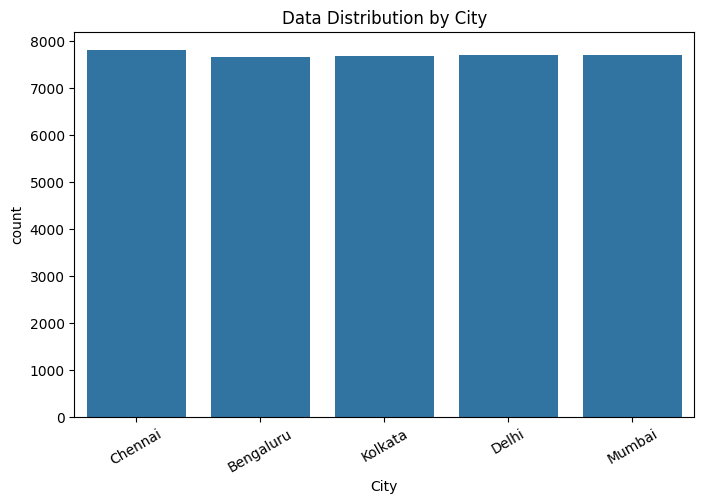

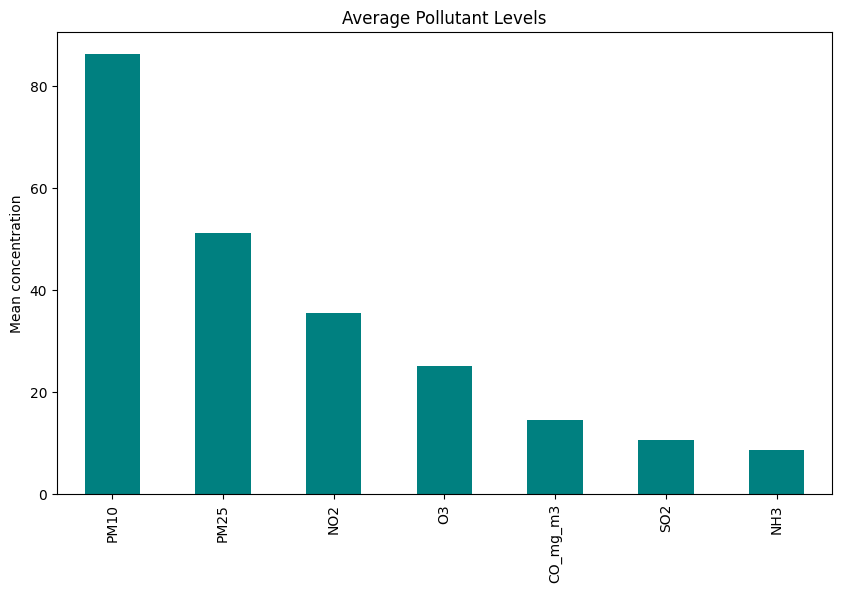

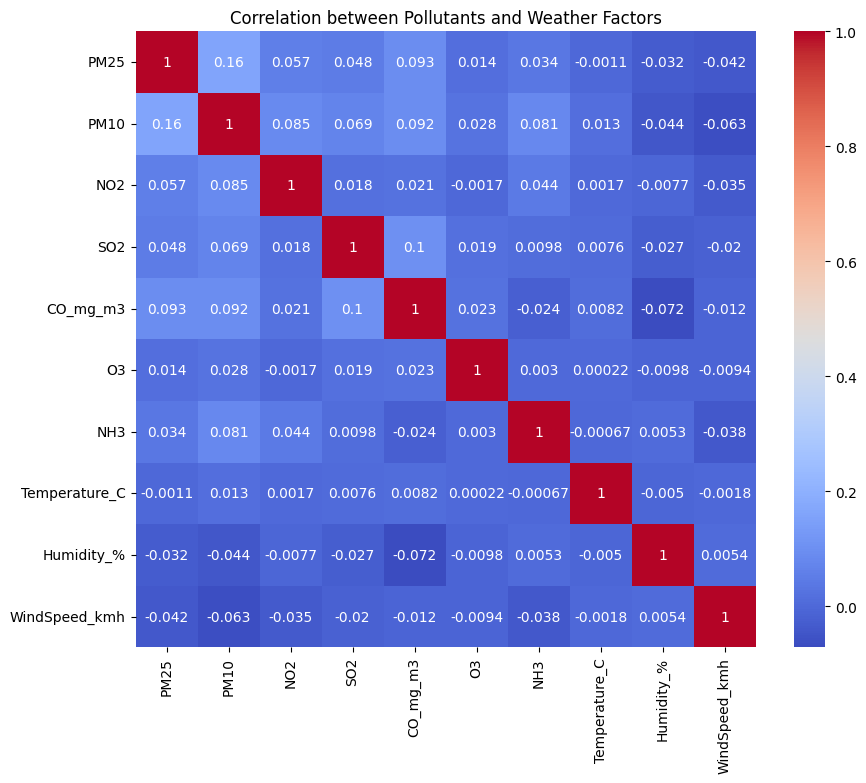

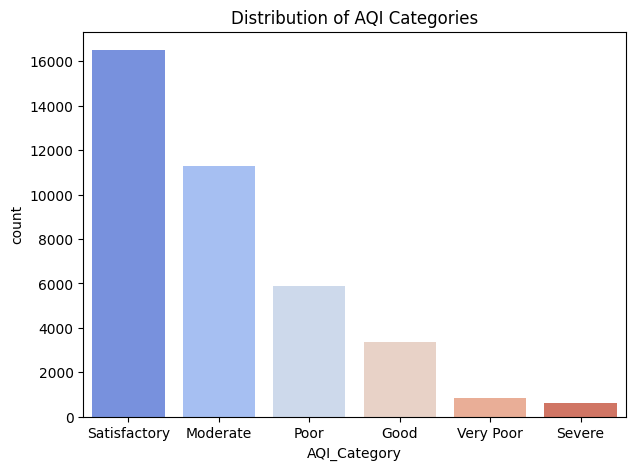


📊 Linear Regression Evaluation:
MAE : 73.15
RMSE: 215.99
R²  : 0.046

📊 Random Forest Evaluation:
MAE : 56.63
RMSE: 232.3
R²  : -0.104


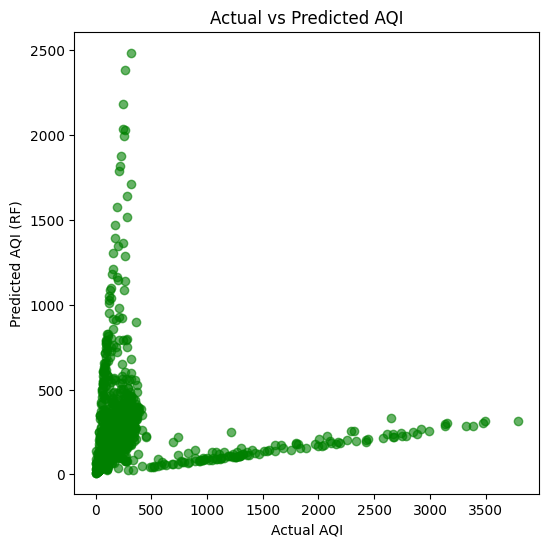

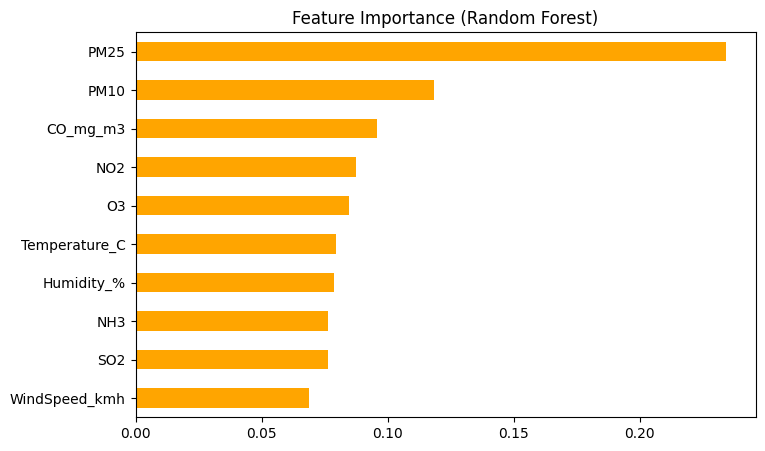


🔍 Insights:
• Highest average pollutants found in: Delhi
• Most influential feature for AQI prediction: PM25
• Model performance suggests Random Forest performs better than Linear Regression.


In [3]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


# =====================================================
# 📘 Air Quality Prediction in Indian Cities
# =====================================================

# --- 1. Import required libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# --- 2. Load dataset ---
# Please upload the 'CPCB+AQ+AccuWeather_Data_Scraped.xlsx' file to your Colab environment (e.g., by dragging it to the file browser).
file_path = r"/content/CPCB+AQ+AccuWeather_Data_Scraped.xlsx"
df = pd.read_excel(file_path)

# --- 3. Basic info ---
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values per column:\n", df.isnull().sum())

# --- 4. Data Cleaning ---
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df = df.dropna(subset=['City', 'Datetime'])
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove duplicates
df = df.drop_duplicates()

# --- 5. Basic EDA ---
print("\nUnique cities:", df['City'].unique())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='City')
plt.title("Data Distribution by City")
plt.xticks(rotation=30)
plt.show()

# --- Pollutant trends ---
pollutants = ['PM25', 'PM10', 'NO2', 'SO2', 'CO_mg_m3', 'O3', 'NH3']

plt.figure(figsize=(10,6))
df[pollutants].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title("Average Pollutant Levels")
plt.ylabel("Mean concentration")
plt.show()

# --- 6. Correlation Heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(df[pollutants + ['Temperature_C', 'Humidity_%', 'WindSpeed_kmh']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Pollutants and Weather Factors")
plt.show()

# --- 7. AQI Classification (based on AQI_proxy) ---
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI_proxy'].apply(classify_aqi)

plt.figure(figsize=(7,5))
sns.countplot(x='AQI_Category', data=df, order=df['AQI_Category'].value_counts().index, palette='coolwarm')
plt.title("Distribution of AQI Categories")
plt.show()

# --- 8. Predictive Modeling ---
# Features (pollutants + weather)
X = df[['PM25', 'PM10', 'NO2', 'SO2', 'CO_mg_m3', 'O3', 'NH3', 'Temperature_C', 'Humidity_%', 'WindSpeed_kmh']]
y = df['AQI_proxy']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Linear Regression Model ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- Random Forest Model ---
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- 9. Evaluation ---
def eval_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Evaluation:")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 2))
    print("R²  :", round(r2_score(y_true, y_pred), 3))

eval_model(y_test, y_pred_lr, "Linear Regression")
eval_model(y_test, y_pred_rf, "Random Forest")

# --- 10. Visualization of Predictions ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI (RF)")
plt.title("Actual vs Predicted AQI")
plt.show()

# --- 11. Feature Importance ---
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='orange')
plt.title("Feature Importance (Random Forest)")
plt.show()

# --- 12. Insights Summary ---
print("\n🔍 Insights:")
print("• Highest average pollutants found in:", df.groupby('City')[pollutants].mean().mean(axis=1).idxmax())
print("• Most influential feature for AQI prediction:", importances.idxmax())
print("• Model performance suggests Random Forest performs better than Linear Regression.")


# In[ ]:

